# tSNE to classify glitches in O3b observation run from LIGO interferometer

This code will use data from O3b observation run from LIGO interferometer to generate glitchgrams. From these, we will construct SNR matrices that will be vectorized. We will apply these vectors to tSNE and plot the scatterplot to see the class separations. It is worth noting that the color visualization will be possible because the classification (glitch labels) has already been done by Gravity Spy. Thus, we only want to confirm if our classification is correct.

## Read data

Let's start by looking at the files in the current path and reading the triggers and glitches from the LIGO O3b run

In [1]:
import os
import pandas as pd

In [2]:
path = os.getcwd()

In [3]:
os.listdir(path)

['.ipynb_checkpoints',
 'glitchgrams_erk.csv',
 'glitchgrams_normalized_erk.csv',
 'glitchgrams_normalized_tbt.csv',
 'GS_o3bL1_unc_triggers_all_classes.csv',
 'GS_selected_glitches_o3b_all_classes.csv',
 'tSNE_LIGO_O3b.ipynb']

In [5]:
path

'C:\\Users\\erick\\Downloads\\jupyternotebook\\LIGO'

In [6]:
trigs = pd.read_csv(path + '\\GS_o3bL1_unc_triggers_all_classes.csv')
glits = pd.read_csv(path + '\\GS_selected_glitches_o3b_all_classes.csv')

In [225]:
trigs

,t0,fc,snr,Q
0,1.256656e+09,23.733904,5.143241,109.179646
1,1.256656e+09,51.983795,5.093652,109.179646
2,1.256656e+09,47.298137,5.404250,109.179646
3,1.256656e+09,47.747037,5.267858,109.179646
4,1.256656e+09,28.941396,5.741380,109.179646
...,...,...,...,...
91127481,1.269012e+09,7619.609604,5.538584,109.179646
91127482,1.269012e+09,7678.963481,5.416616,57.841897
91127483,1.269012e+09,7543.220855,5.016661,57.841897
91127484,1.269012e+09,7619.609604,5.131701,109.179646


In [229]:
glits['snr'].min()

7.5

In [9]:
glits = glits.drop(columns=['Unnamed: 0'])

## Generating the data

Here we will generate the glitchgrams and store them in our current path. Choose one of the programmers below to run the code.

In [11]:
import numpy as np
import time
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn import manifold
from sklearn.manifold import TSNE

import warnings
warnings.filterwarnings("ignore")

In [12]:
unclustered = trigs.copy()
unclustered = unclustered.sort_values(by=['t0'])

clustered = glits.copy()
clustered = clustered.sort_values(by=['GPStime'])

### Erick's code - is called 10k times, one for each glitchgram: 

In [13]:
def glitch_to_glitchgram(df_triggers, tmin, tmax, 
                         fmin=3, fmax=8192, n_time_bins=41, n_freq_bins=30, norm=False):

    """
    This function create one glitchgram from unclustered Omicron data, for each glitch.

    Parameters:
        df_triggers (dataFrame): A dataFrame of GPStimes of all triggers inside of some window.
        tmin, tmax (numbers): limits of GPStimes that contain all triggers of some glitch.
        fmin, fmax (numbers): frequency range for the glitchgram.
        n_time_bins (int): number of time bins.
        n_freq_bins (int): number of frequency bins.
        norm (boolean): True if you need normalize SNR values.

    Returns:
        array for some glitch: each entry is a SNR value from flattened (binsf × binst) matrix.
    """
    
    times = df_triggers['t0'].values
    freqs = df_triggers['fc'].values
    snrs  = df_triggers['snr'].values

    time_edges = np.linspace(tmin, tmax, n_time_bins+1)
    freq_edges = np.logspace(np.log10(fmin), np.log10(fmax), n_freq_bins+1)

    """ bin index for each trigger """
    t_idx = np.digitize(times, time_edges) - 1
    f_idx = np.digitize(freqs, freq_edges) - 1

    # initial matrix
    A = np.zeros((n_freq_bins, n_time_bins), dtype=float)

    """ if we use 'count' or 'mean', we need counters """

    for ti, fi, si in zip(t_idx, f_idx, snrs):
        if 0 <= ti < n_time_bins and 0 <= fi < n_freq_bins:
            if si > A[fi, ti]:
                A[fi, ti] = si

    snrs = A.flatten(order="C")

    """ SNR normalization """
    if norm == True:
        snrs = np.array(snrs)
    
        snr_min = snrs.min()
        snr_max = snrs.max()
    
        if snr_max > snr_min:
            snrs = (snrs - snr_min) / (snr_max - snr_min)
    
    return snrs

In [14]:
times_all = unclustered["t0"].values
freqs_all = unclustered["fc"].values
snrs_all  = unclustered["snr"].values

vec_erk = []

for i, row in enumerate(clustered.itertuples(index=False)):

    t_center = row.GPStime

    dt = 1.0
    tmin = t_center - dt/2
    tmax = t_center + dt/2

    # finds range indices
    i0 = np.searchsorted(times_all, tmin, side="left")
    i1 = np.searchsorted(times_all, tmax, side="right")

    # selects triggers only within the range
    times = times_all[i0:i1]
    freqs = freqs_all[i0:i1]
    snrs  = snrs_all[i0:i1]
    
    df_sel = pd.DataFrame({"t0": times, "fc": freqs, "snr": snrs})

    # df_sel = unclustered[(unclustered['t0'] >= tmin) & (unclustered['t0'] <= tmax)].copy()

    if (i % 200) == 0:
        print(f"Glitch {i} - {len(df_sel)} triggers")

    V = glitch_to_glitchgram(df_sel, tmin, tmax)
    vec_erk.append(V)

Glitch 0 - 3394 triggers
Glitch 200 - 862 triggers
Glitch 400 - 123 triggers
Glitch 600 - 327 triggers
Glitch 800 - 11862 triggers
Glitch 1000 - 537 triggers
Glitch 1200 - 3561 triggers
Glitch 1400 - 90 triggers
Glitch 1600 - 139 triggers
Glitch 1800 - 245 triggers
Glitch 2000 - 107 triggers
Glitch 2200 - 183 triggers
Glitch 2400 - 1179 triggers
Glitch 2600 - 89 triggers
Glitch 2800 - 1302 triggers
Glitch 3000 - 10587 triggers
Glitch 3200 - 119 triggers
Glitch 3400 - 54 triggers
Glitch 3600 - 80795 triggers
Glitch 3800 - 96 triggers
Glitch 4000 - 125 triggers
Glitch 4200 - 60 triggers
Glitch 4400 - 15129 triggers
Glitch 4600 - 435 triggers
Glitch 4800 - 337 triggers


KeyboardInterrupt: 

In [67]:
vec_pd = pd.DataFrame(vec_erk)
vec_pd.to_csv(path + '\\glitchgrams_erk.csv', index=False)

### Tabata's code - is called one time and give the final result: 

~ this will take a while

In [144]:
def glitchappend_norm_snr(gpstimes, q1, q2, deltat, unclusted_file, 
                          freq_min=3, freq_max=8192, binst=41, binsf=30, norm=False):
    """
    This function normalizes glitchgrams from unclustered Omicron data.

    Parameters:
        gpstimes (list): A list of GPS times to create glitchgrams.
        q1 (number): Minimum q-value.
        q2 (number): Maximum q-value.
        deltat (number): Interval around GPS time to take triggers.
        unclusted_file (.pkl): File with unclustered triggers.
        freq_min, freq_max: frequency range for the glitchgram.
        binst (int): number of time bins.
        binsf (int): number of frequency bins.
        norm (boolean): True if you need normalize SNR values.

    Returns:
        list of 1D arrays: each entry is a flattened (binsf × binst) matrix.
    """

    t0  = np.array(unclusted_file['t0'])
    fc  = np.array(unclusted_file['fc'])
    q   = np.array(unclusted_file['Q'])
    snr = np.array(unclusted_file['snr'])

    nt = binst    # number of time bins
    nf = binsf    # number of frequency bins

    X = []

    # EDGES dos bins (nt+1, nf+1) – igual ao que você usa no plot
    tbins = np.linspace(-deltat, deltat, nt + 1)  # 42 edges -> 41 bins
    fbins = np.logspace(np.log10(freq_min), np.log10(freq_max), nf + 1)

    N = len(gpstimes)

    for idx in range(N):

        selected1 = np.logical_and(t0 > (gpstimes[idx] - deltat),
                                   t0 < (gpstimes[idx] + deltat))
        selected2 = np.logical_and(q >= q1, q <= q2)
        selected  = np.logical_and(selected1, selected2)

        snrs = snr[selected]
        t0s  = t0[selected] - gpstimes[idx]
        fcs  = fc[selected]

        # índices dos bins (0..nt-1, 0..nf-1)
        tindx = np.digitize(t0s, tbins) - 1
        findx = np.digitize(fcs, fbins) - 1

        # normalização do SNR 
        if len(snrs) > 0:
            snr_min = snrs.min()
            snr_max = snrs.max()
            if snr_max > snr_min:
                norm_snrs = (snrs - snr_min) / (snr_max - snr_min)
            else:
                norm_snrs = np.zeros_like(snrs)
        else:
            norm_snrs = snrs  # vazio

        m = np.zeros((nf, nt))

        for i in range(len(norm_snrs)):
            ti = tindx[i]
            fi = findx[i]
            if 0 <= ti < nt and 0 <= fi < nf:
                if m[fi, ti] < norm_snrs[i]:
                    m[fi, ti] = norm_snrs[i]

        X.append(m.flatten(order='C'))

    return X

In [164]:
q1, q2 = 1, 1000
dt = 0.5
gpstimes = clustered['GPStime'].values

In [165]:
glitches_tbt = glitchappend_norm_snr(gpstimes, q1, q2, dt, unclustered)

In [166]:
glitches_tbt_pd = pd.DataFrame(glitches_tbt)
glitches_tbt_pd.to_csv(path + '\\glitchgrams_norm_tbt.csv')

## tSNE and results

In [22]:
!pip install --upgrade joblib loky


  Attempting uninstall: joblib

    Found existing installation: joblib 1.4.2

    Uninstalling joblib-1.4.2:

      Successfully uninstalled joblib-1.4.2

   -------------------- ------------------- 1/2 [joblib]
   -------------------- ------------------- 1/2 [joblib]
   -------------------- ------------------- 1/2 [joblib]
   -------------------- ------------------- 1/2 [joblib]
   ---------------------------------------- 2/2 [joblib]



In [278]:
seed, pl1 = 0, 30
tsne = TSNE(n_components=2, perplexity=pl1, learning_rate=200, max_iter=1000, metric="euclidean", random_state=seed)

labs = LabelEncoder().fit_transform(clustered['label'])

### standard results

In [300]:
vec = pd.read_csv(path + '\\glitchgrams_erk.csv')
vecnorm = pd.read_csv(path + '\\glitchgrams_normalized_erk.csv')

proj = tsne.fit_transform(vec)
projn = tsne.fit_transform(vecnorm)

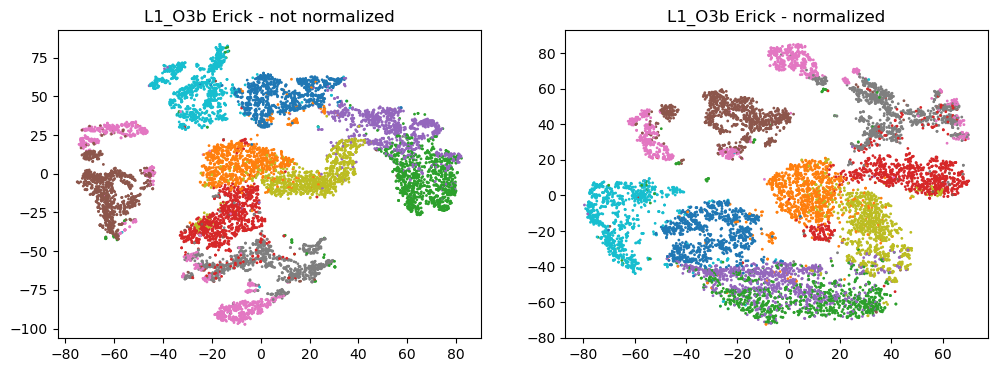

In [302]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))
axs = np.atleast_1d(axs)
cmap = plt.cm.get_cmap("tab10")

axs[0].set_title(f'L1_O3b Erick - not normalized')
axs[0].scatter(proj[:,0], proj[:,1], s=1, c=labs, cmap=cmap)

axs[1].set_title(f'L1_O3b Erick - normalized')
axs[1].scatter(projn[:,0], projn[:,1], s=1, c=labs, cmap=cmap)

plt.show()

In [297]:
# vect = pd.read_csv(path + '\\glitchgrams_tbt.csv')
vecnormt = pd.read_csv(path + '\\glitchgrams_normalized_tbt.csv')

# projt = tsne.fit_transform(vect)
projnt = tsne.fit_transform(vecnormt)

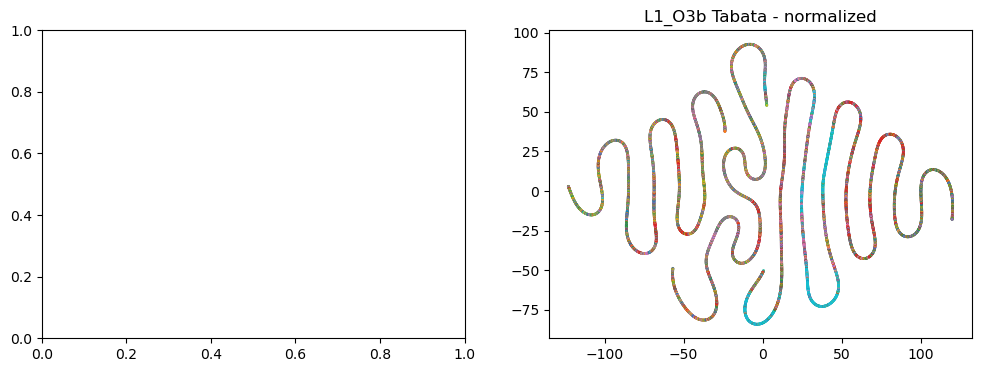

In [299]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))
axs = np.atleast_1d(axs)
cmap = plt.cm.get_cmap("tab10")

# axs[0].set_title(f'L1_O3b Tabata - not normalized')
# axs[0].scatter(projt[:,0], projt[:,1], s=1, c=labs, cmap=cmap)

axs[1].set_title(f'L1_O3b Tabata - normalized')
axs[1].scatter(projnt[:,0], projnt[:,1], s=1, c=labs, cmap=cmap)

plt.show()

### If you need cut triggers count

In [265]:
vec.shape

(10000, 1230)

In [258]:
triggers_por_glitch = (vec != 0).sum(axis=1)

In [268]:
triggers_por_glitch.values

array([203, 513,  44, ...,  34, 629, 184])

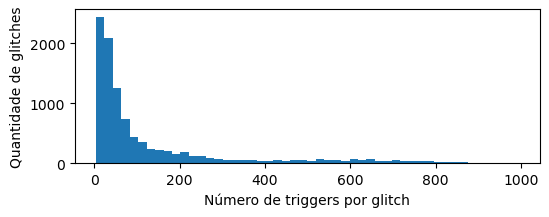

In [275]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,2))

plt.hist(triggers_por_glitch, bins=50)
plt.xlabel("Número de triggers por glitch")
plt.ylabel("Quantidade de glitches")
plt.show()

In [290]:
limit = 10

mask = triggers_por_glitch >= limit

In [285]:
vec_filt = vec[mask]
labs_filt = LabelEncoder().fit_transform(clustered['label'])[mask]

In [286]:
vec_filt.shape

(9576, 1230)

In [287]:
proj_teste = tsne.fit_transform(vec_filt)

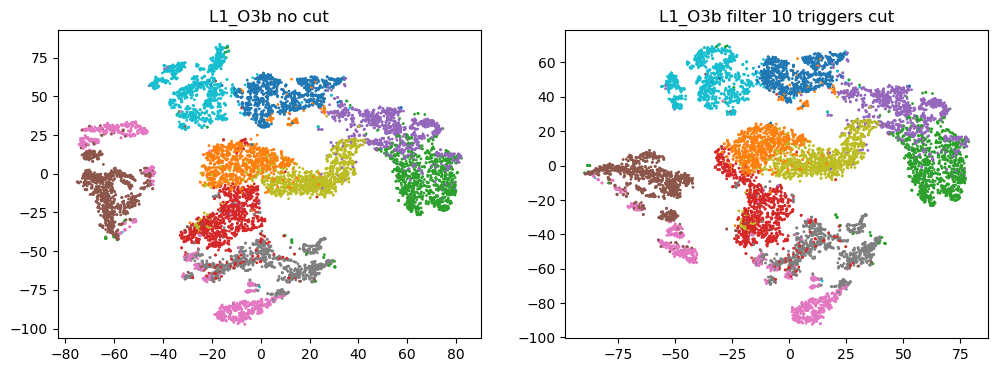

In [295]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))
axs = np.atleast_1d(axs)
cmap = plt.cm.get_cmap("tab10")

axs[0].set_title(f'L1_O3b no cut')
axs[0].scatter(proj[:,0], proj[:,1], s=1, c=labs, cmap=cmap)

axs[1].set_title(f'L1_O3b filter {limit} triggers cut')
axs[1].scatter(proj_teste[:,0], proj_teste[:,1], s=1, c=labs_filt, cmap=cmap)

plt.show()

### tSNE 3D preview

In [30]:
seed, pl1 = 0, 30
tsne1d = TSNE(n_components=3, perplexity=pl1, learning_rate=200, max_iter=1000, metric="euclidean", random_state=seed)

labs = LabelEncoder().fit_transform(clustered['label'])

In [31]:
vec2 = pd.read_csv(path + '\\glitchgrams_erk.csv')
vecnorm2 = pd.read_csv(path + '\\glitchgrams_normalized_erk.csv')

proj2 = tsne1d.fit_transform(vec2)
projn2 = tsne1d.fit_transform(vecnorm2)

In [32]:
proj2

array([[  4.3096066,   6.4621816,  -8.783681 ],
       [ 15.381551 ,   4.17161  ,  -8.473101 ],
       [  5.601336 , -18.801548 ,   3.3707626],
       ...,
       [ 10.9038315,  -3.5921378,  12.5656805],
       [ 19.026054 ,  -2.913966 ,  -4.466737 ],
       [ 12.398954 ,   9.0748825, -14.072391 ]], dtype=float32)

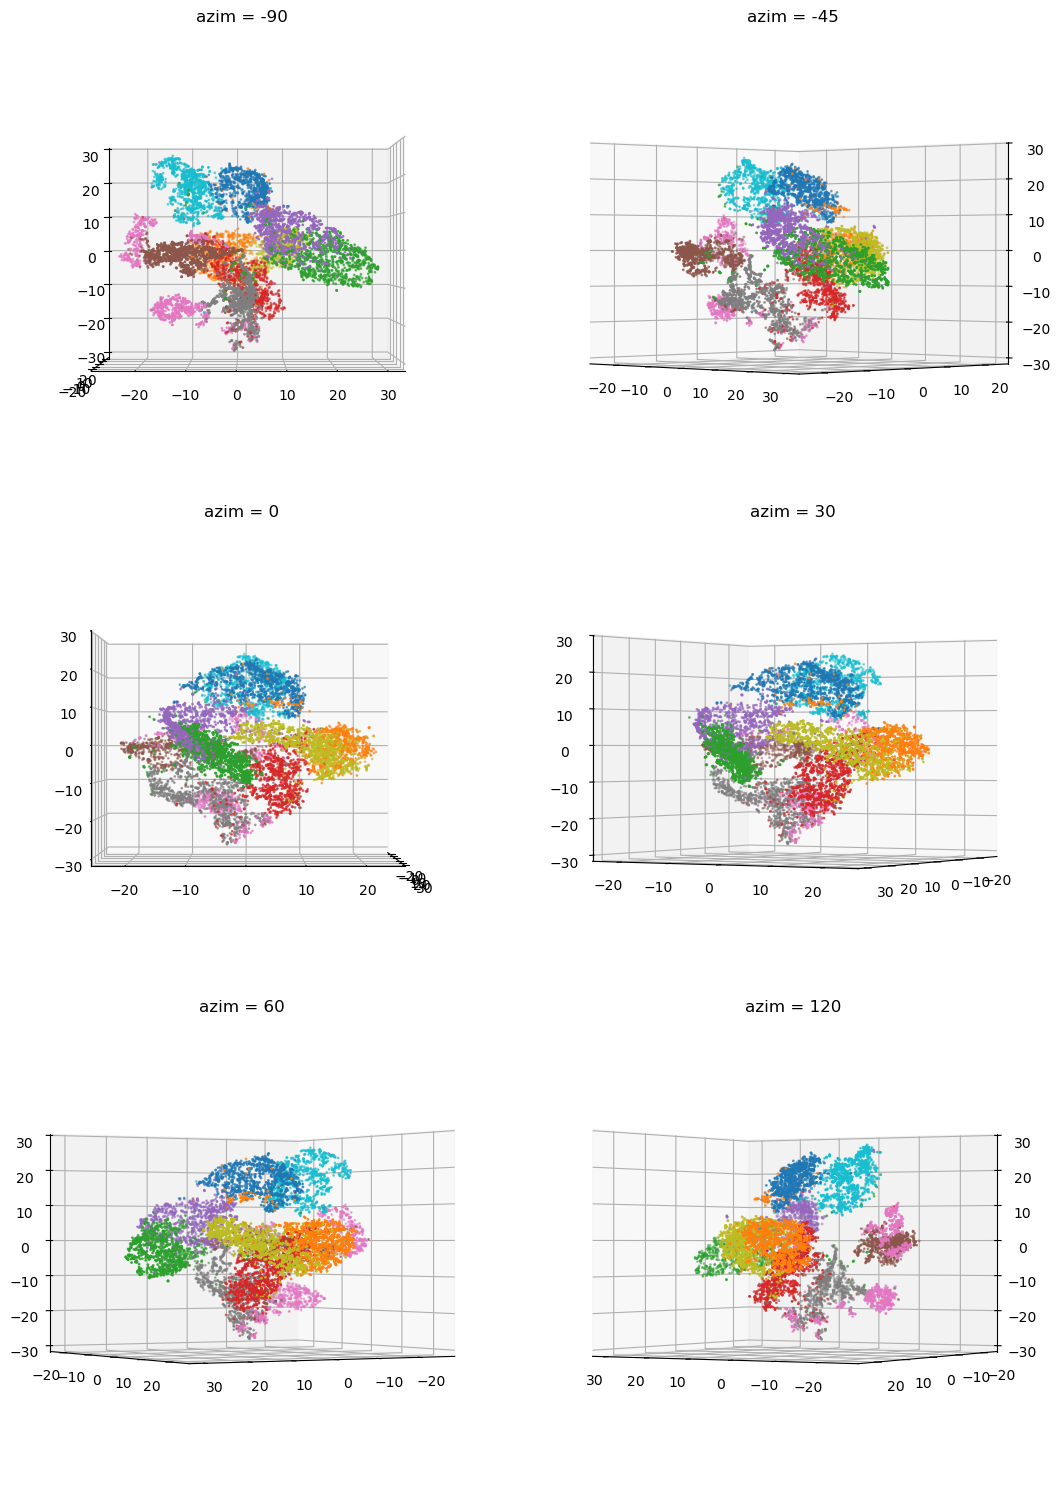

In [223]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(3, 2, figsize=(12, 15), subplot_kw={'projection':'3d'})
cmap = plt.cm.get_cmap("tab10")

allazim = [-90, -45, 0, 30, 60, 120]

for ax, az in zip(axs.flatten(), allazim):

    ax.scatter(proj2[:,0], proj2[:,2], proj2[:,1], s=1, c=labs, cmap=cmap)

    ax.view_init(elev=0, azim=az)
    ax.set_title(f"azim = {az}")

plt.tight_layout()
plt.show()

tSNE com SNR no terceiro eixo

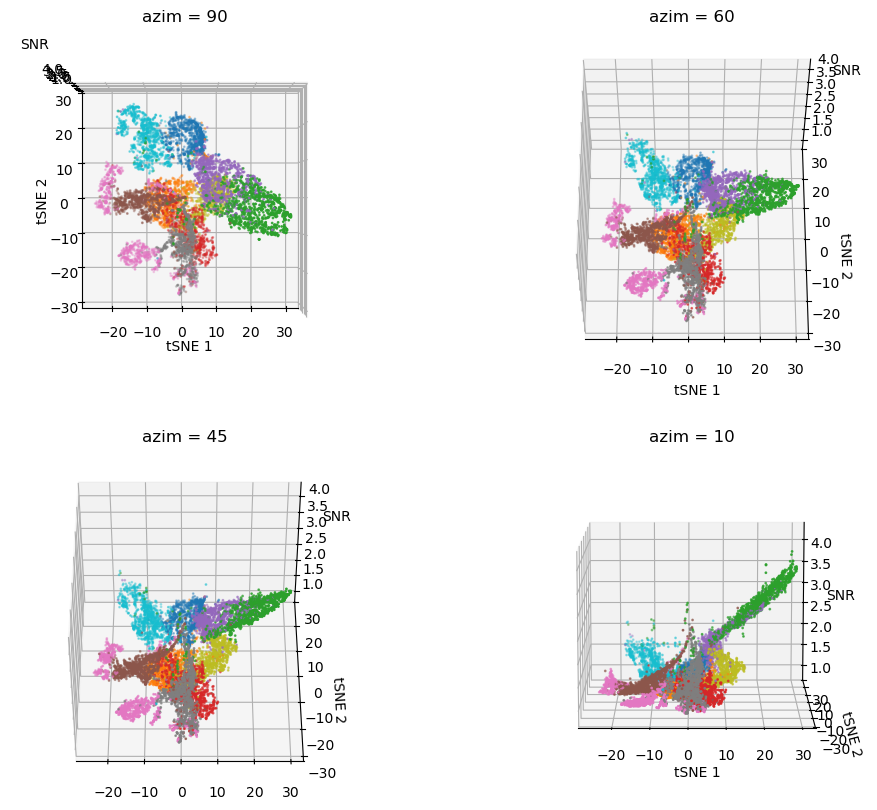

In [308]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(2, 2, figsize=(12,10), subplot_kw={'projection':'3d'})
cmap = plt.cm.get_cmap("tab10")

allelevs = [90, 60, 45, 10]

x = proj2[:,0]
y = proj2[:,1]
snr = clustered['snr']
z = np.log10(snr)

for ax, el in zip(axs.flatten(), allelevs):

    ax.scatter(x, y, z, s=1, c=labs, cmap=cmap)
    ax.view_init(elev=el, azim=-90)

    ax.set_title(f'azim = {el}')
    ax.set_xlabel("tSNE 1")
    ax.set_ylabel("tSNE 2")
    ax.set_zlabel("SNR")

plt.show()